In [177]:
from sklearn.datasets      import make_multilabel_classification
from sklearn.metrics       import classification_report
from sklearn.metrics       import label_ranking_loss
from sklearn.preprocessing import OneHotEncoder

import matplotlib.pyplot   as plt
from collections import OrderedDict

import torch
torch.manual_seed(seed = 42)

import torch.nn as nn
from torch.utils.data        import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from tqdm import tqdm
device = torch.device("cpu") #torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print("Device", device)


Device cpu


In [178]:
def train_model(model,device, optimizer ,data_loader, loss_module, num_epochs=100):
    model.train()
    train_losses  = []
    for epoch in tqdm(range(num_epochs)):
        for data_inputs, data_labels in data_loader:
            # Put training data into GPU
            data_inputs = data_inputs.to(device)
            data_labels = data_labels.to(device)

            preds = model(data_inputs).to(device)
            loss  = loss_module(preds, data_labels)
            train_losses.append(loss.item())

            # Zero the gradients
            optimizer.zero_grad()
            loss     .backward()
            optimizer.step()

    return train_losses

In [179]:
@torch.no_grad()
def eval_model(model, device, data_loader, target_names = False):
    model.eval()
    all_pred   = torch.empty((0,), dtype = torch.float32).to(device)
    all_labels = torch.empty((0,), dtype = torch.float32).to(device)

    for data_inputs, data_labels in data_loader:
        data_inputs = data_inputs.to(device)
        data_labels = data_labels.to(device)
        preds = model(data_inputs)
        #preds = preds.squeeze(dim=1)
        pred_labels = (preds >= 0.5).long().to(device)
        all_pred   = torch.cat((all_pred,pred_labels), dim = 0 )
        all_labels = torch.cat((all_labels,data_labels))
    print(classification_report(y_pred =   all_pred.cpu().numpy(), 
                                y_true = all_labels.cpu().numpy(), 
                                zero_division = 0))


In [180]:
X, y = make_multilabel_classification(n_features      = 20,
                                      length          = 10,
                                      n_samples       = 100,
                                      n_classes       = 5,
                                      n_labels        = 2,
                                      allow_unlabeled = False,
                                      random_state    = 42)
print(X.shape)
print(y.shape)
print(y[0])

(100, 20)
(100, 5)
[0 0 0 1 0]


In [181]:
X_train, X_test, Y_train, Y_test = train_test_split(X,y, test_size = 0.2,random_state = 42) 

X_train = torch.from_numpy(X_train).type(torch.float32)
Y_train = torch.from_numpy(Y_train).type(torch.float32)

X_test  = torch.from_numpy(X_test) .type(torch.float32)
Y_test  = torch.from_numpy(Y_test) .type(torch.float32)

training_dataset = TensorDataset(X_train,Y_train)
testing_dataset  = TensorDataset(X_test ,Y_test )

train_loader = DataLoader(TensorDataset(X_train,Y_train) , batch_size = X_train.shape[0], shuffle = False)
test_loader  = DataLoader(TensorDataset(X_test ,Y_test ) , batch_size = X_test.shape[0] , shuffle = False)

In [182]:
def generate_model():
    model = nn.Sequential(
        nn.Linear(20, 100),
        nn.Dropout(0.2),
        nn.ReLU(),
        nn.Linear(100, 100),
        nn.Dropout(0.2),
        nn.ReLU(),
        nn.Linear(100, 5),
        nn.Sigmoid()
    )
    return model
model = generate_model()

loss_module = torch.nn.BCELoss()
optimizer   = torch.optim.Adam(model.parameters(), lr=0.01, betas = (0.9,0.99)) #(0.1,0.3)

In [183]:
eval_model(model        = model,
           device       = device,
           data_loader  = test_loader,
           target_names = [f'Label {i}' for i in range(y.shape[1])])

              precision    recall  f1-score   support

           0       0.50      0.50      0.50         8
           1       0.58      1.00      0.73        11
           2       0.29      0.20      0.24        10
           3       0.00      0.00      0.00         5
           4       0.00      0.00      0.00         0

   micro avg       0.33      0.50      0.40        34
   macro avg       0.27      0.34      0.29        34
weighted avg       0.39      0.50      0.42        34
 samples avg       0.40      0.51      0.40        34



In [184]:
hist = train_model(model       = model,
                   device      = device,
                   optimizer   = optimizer,
                   data_loader = train_loader,
                   loss_module = loss_module,
                   num_epochs  = 200)

100%|██████████| 200/200 [00:00<00:00, 890.04it/s]


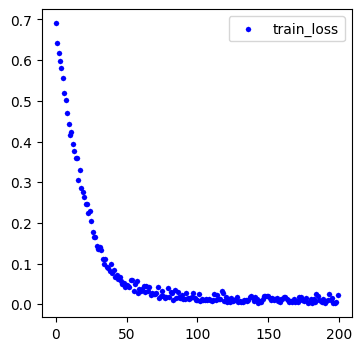

In [185]:
plt.figure(figsize=(4,4))
plt.scatter(y = hist,
            x = [_ for _ in range(len(hist))],
            alpha = 1, lw = 0.1, c = 'b', s = 14, label = 'train_loss')
plt.legend(); plt.show()

---

In [186]:
def client_data_split(dataset: TensorDataset, n_clients:  int):
    """Split the training dataset into n_clients parts"""
    client_data_pool = []
    splits = list( torch.linspace(0, len(dataset) - 1, steps = n_clients + 1).long() )
    for idx in range(0,len(splits) - 1):
        l,r = splits[idx:idx + 2]
        l,r = l.item(),r.item()
        #sprint(l,r)
        client_data_pool.append(dataset[l:r,:])
    return client_data_pool

### Need to make sure that each client has their own loss module and optimizer
- 1) Initiate a global model
- 2) Pass the param to each client
- 3) train each client with its respective dataset.
- 4) Aggregate model param from all the clients (FedAvg)
- 5) Load param back in global model
- 6) Repeat steps 1 - 5 until model converges

In [187]:
def train_client(model,device , train_set , num_epochs=1):
    loss_module = torch.nn.BCELoss()
    optimizer   = torch.optim.SGD(model.parameters(), lr=0.001)
    train_loader = DataLoader(TensorDataset(train_set[0],train_set[1]) , batch_size = 10, shuffle = False)
    
    model.train()
    train_losses  = []
    for epoch in (range(num_epochs)):
        for data_inputs, data_labels in train_loader:
            # Put training data into GPU
            data_inputs = data_inputs.to(device)
            data_labels = data_labels.to(device)

            preds = model(data_inputs).to(device)
            loss  = loss_module(preds, data_labels)
            train_losses.append(loss.item())

            # Zero the gradients
            optimizer.zero_grad()
            loss     .backward()
            optimizer.step()

    return train_losses

In [188]:
client_data = client_data_split(dataset = training_dataset, n_clients = 3)

In [189]:
def FedAvg(param_pool: list[OrderedDict]):
    num_clients = len(param_pool)
    result = { k : torch.zeros(size = v.shape) for k ,v in param_pool[0].items() } 
    for k,v in result.items():
        result[k] = (sum([model[k] for model in param_pool]) / num_clients)
    return result

In [190]:
testing_dataset = TensorDataset(X_test ,Y_test )
test_loader     = DataLoader(TensorDataset(X_test ,Y_test ) , batch_size = X_test.shape[0] , shuffle = False)

In [191]:
n_clients    = 3
clients      = [generate_model() for _ in range(3)]
# 1 Initate a global model
global_model = generate_model()
param_pool   = [c.state_dict() for c in clients]
client_loss = [[] for _ in range(n_clients)]

for rounds in tqdm(range(1000)):
    for idx, c in enumerate(clients):
        # 2 load in global_model into each client
        c.load_state_dict(global_model.state_dict())

        # 3 Train each client on their respective dataset
        loss = train_client(model  = c, 
                        device = torch.device('cpu'), 
                        train_set  = client_data[idx],
                        num_epochs = 1)
        client_loss[idx].extend(loss)        
        # Collect each parameter
        param_pool[idx] = c.state_dict()
    
    # 4 Aggregate model param
    new_param = FedAvg(param_pool)
    # 5 Load Model param back into global model
    global_model.load_state_dict(new_param)

    #eval_model(model = global_model, device= torch.device('cpu'), data_loader =test_loader)

100%|██████████| 1000/1000 [00:04<00:00, 240.32it/s]


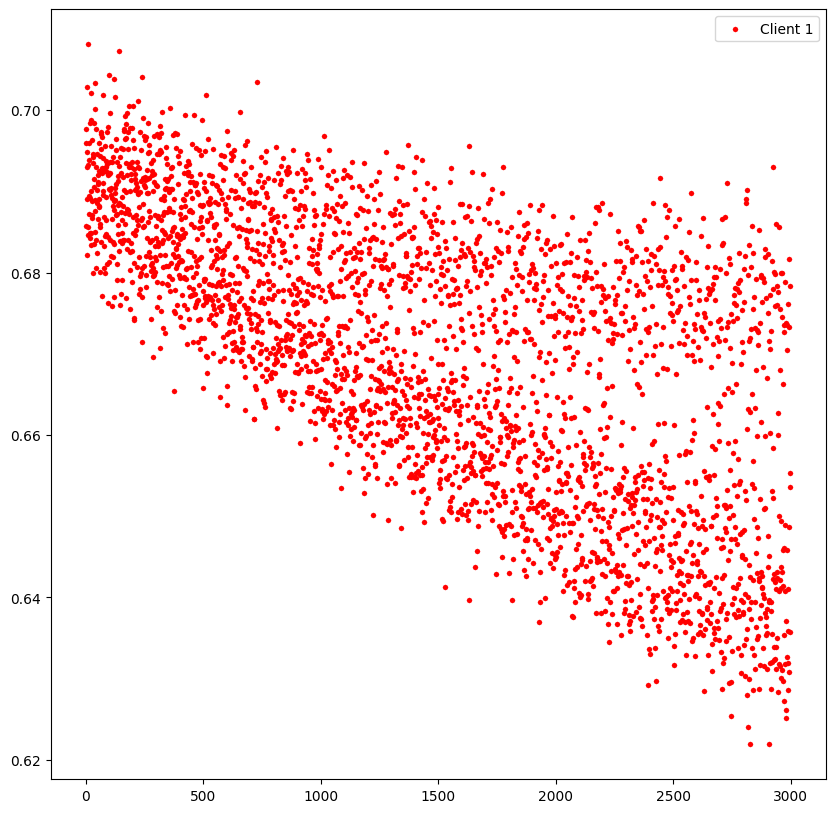

In [193]:

plt.figure(figsize=(10,10))
plt.scatter(y = client_loss[0],
            x = [_ for _ in range(len(client_loss[0]))],
            alpha = 1, lw = 0.1, c = 'r', s = 14, label = 'Client 1')
# plt.scatter(y = client_loss[1],
#             x = [_ for _ in range(len(client_loss[1]))],
#             alpha = 1, lw = 0.1, c = 'g', s = 14, label = 'Client 2')
# plt.scatter(y = client_loss[2],
#             x = [_ for _ in range(len(client_loss[2]))],
#             alpha = 1, lw = 0.1, c = 'b', s = 14, label = 'Client 3')
plt.legend()
plt.show()